# **Step 1 :Load,Explore & Preprocess**

# **Import Libraries**

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# **Load Dataset**

In [4]:
import pandas as pd

df = pd.read_csv('/content/heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

#Show Data Types of each columns
print("\nData Types:")
print(df.dtypes)

# Information about Number of Missing value
print("\nMissing Values:")
print(df.isnull().sum())

# Information about Number of Duplicate values
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Information about columns
print("\nDataset Information:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(1025, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows:
723

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1

# **Remove Duplicate Rows**

In [6]:
df = df.drop_duplicates()
print(df.shape)

(302, 14)


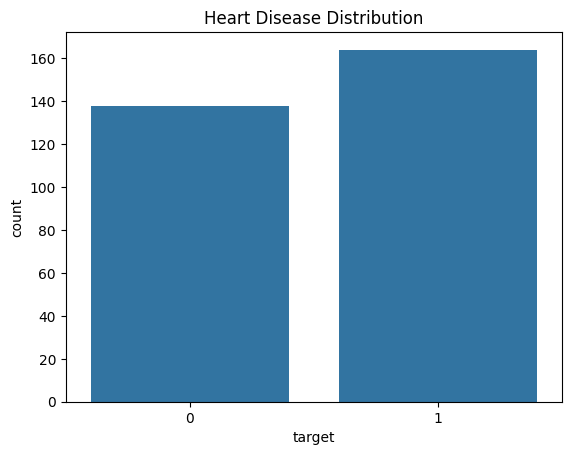

In [7]:
# Visualize class distribution

sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

# **Step 2:**  **FEATURE ENGINEERING**

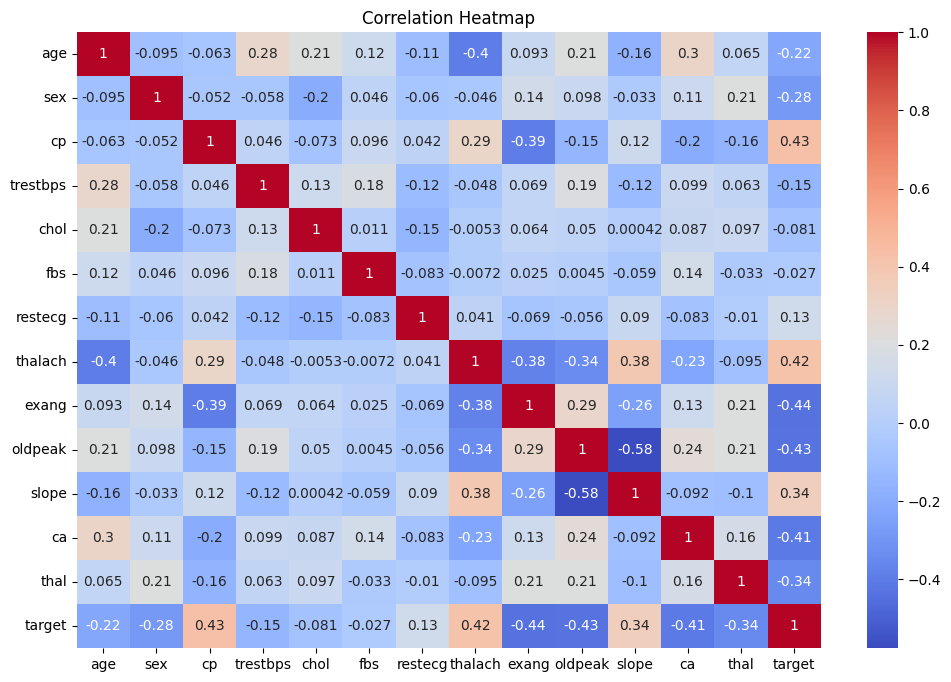

In [8]:
# Correlation between features

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
# Independent variables

X = df.drop("target", axis=1)

# Dependent variable

y = df["target"]

In [10]:
# Temporary Random Forest model

rf_temp = RandomForestClassifier(random_state=42)

rf_temp.fit(X, y)

# Calculate importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
})

# Sort values

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
7    thalach    0.134202
2         cp    0.128033
9    oldpeak    0.115018
11        ca    0.108043
12      thal    0.099852
0        age    0.090054
4       chol    0.074063
3   trestbps    0.071019
8      exang    0.060830
10     slope    0.051134
1        sex    0.038703
6    restecg    0.021519
5        fbs    0.007529


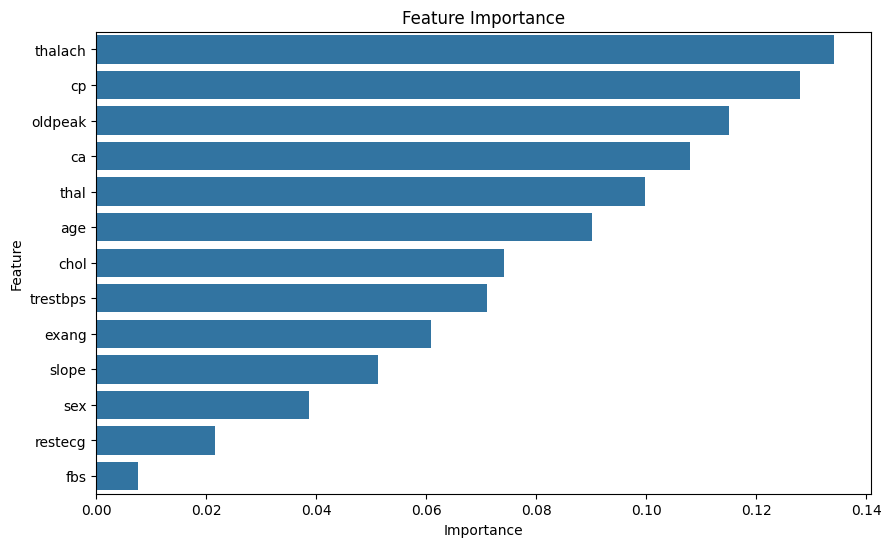

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

# **Step 3: Train 3 Different Models**

# **TRAIN TEST SPLIT**

In [12]:
# 80% Training
# 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# **FEATURE SCALING**

In [13]:
# Create scaler

scaler = StandardScaler()

# Fit and transform training data

X_train_scaled = scaler.fit_transform(X_train)

# Transform test data

X_test_scaled = scaler.transform(X_test)

# **MODEL 1** **Logistic Regression**

In [14]:
# Create model

lr = LogisticRegression(max_iter=1000)

# Train model

lr.fit(X_train_scaled, y_train)

# Predict

lr_pred = lr.predict(X_test_scaled)

# **MODEL 2 :Random Forest**

In [15]:
# Create model

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model

rf.fit(X_train, y_train)

# Predict

rf_pred = rf.predict(X_test)

# **MODEL 3:KNN**

In [16]:
# Create model

knn = KNeighborsClassifier(
    n_neighbors=5
)

# Train model

knn.fit(X_train_scaled, y_train)

# Predict

knn_pred = knn.predict(X_test_scaled)

# **Step 4:** **EVALUATION**

In [17]:
def evaluate_model(name, y_test, predictions):

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    return [
        name,
        accuracy,
        precision,
        recall,
        f1
    ]

In [18]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "KNN",
        y_test,
        knn_pred
    )
)

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,Random Forest,0.754098,0.764706,0.787879,0.776119
2,KNN,0.786885,0.777778,0.848485,0.811594


In [19]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
2,KNN,0.786885,0.777778,0.848485,0.811594
1,Random Forest,0.754098,0.764706,0.787879,0.776119


#  **Step 5: Best Model Analysis & Conclusion**

After evaluating all three machine learning models, Logistic Regression was selected as the best-performing model because it achieved the highest Accuracy, Precision, and F1 Score. To further analyze its performance, a confusion matrix and classification report are generated.

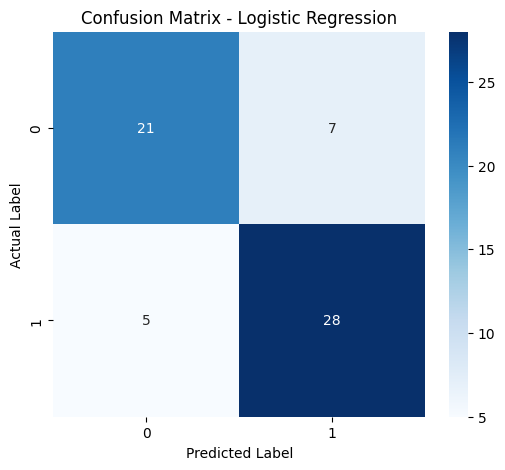

In [22]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Create confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, lr_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Why do we use a Confusion Matrix?

A confusion matrix helps us evaluate the performance of the classification model by showing the number of correctly and incorrectly classified instances. It provides detailed information about True Positives, True Negatives, False Positives, and False Negatives, which helps in understanding the strengths and weaknesses of the model.

In [23]:
# Display Classification Report

print("Classification Report for Logistic Regression:\n")

print(classification_report(y_test, lr_pred))

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



## Best Model Analysis

Three machine learning models—Logistic Regression, Random Forest, and K-Nearest Neighbors (KNN)—were trained and evaluated. Logistic Regression achieved the highest Accuracy (80.33%), Precision (80.00%), and F1 Score (82.35%), making it the best-performing model. The confusion matrix and classification report indicate that the model correctly classified most of the samples while maintaining a good balance between precision and recall. Due to its strong predictive performance and simplicity, Logistic Regression was selected as the final model for heart disease prediction.

## Conclusion

1. The Heart Disease dataset was successfully preprocessed by checking for missing values, removing duplicate records, and scaling the required features.

2. Three machine learning models—Logistic Regression, Random Forest, and K-Nearest Neighbors (KNN)—were trained and evaluated using Accuracy, Precision, Recall, and F1 Score.

3. Logistic Regression achieved the highest Accuracy (80.33%) and F1 Score (82.35%), making it the best-performing model.

4. The confusion matrix and classification report confirmed that Logistic Regression produced reliable predictions for both classes.

5. Therefore, Logistic Regression was selected as the final model for heart disease prediction because of its balanced performance and good generalization on the dataset.